# House Price Prediction using Machine Learning

This project predicts house prices using regression techniques.  
The dataset is taken from Kaggle Housing Prices competition.

## Objective
To build a machine learning model that can accurately predict house prices based on features like area, location, and other attributes.

In [36]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Load the data, and separate the target
iowa_file_path = '/content/train.csv'
home_data = pd.read_csv(iowa_file_path)
y = home_data.SalePrice

# Create X (After completing the exercise, you can return to modify this line!)
features = ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']

# Select columns corresponding to features, and preview the data
X = home_data[features]
X.head()

# Split into validation and training data
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# Define a random forest model
rf_model = RandomForestRegressor(random_state=1)
rf_model.fit(train_X, train_y)
rf_val_predictions = rf_model.predict(val_X)
rf_val_mae = mean_absolute_error(rf_val_predictions, val_y)

print("Validation MAE for Random Forest Model: {:,.0f}".format(rf_val_mae))

Validation MAE for Random Forest Model: 21,857


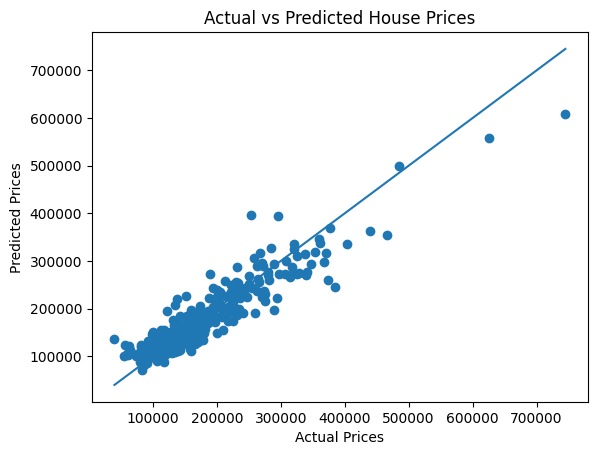

In [37]:
plt.scatter(val_y, rf_val_predictions)
plt.plot([min(val_y), max(val_y)], [min(val_y), max(val_y)])
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Results

- Model: Random Forest Regressor  
- Validation MAE: 21,857  
- Dataset: Kaggle Housing Prices  

The model performs reasonably well and can be further improved using feature engineering and hyperparameter tuning.

In [38]:
# To improve accuracy,Random Forest model is trained on all training data
rf_model_on_full_data = RandomForestRegressor()

# fitting rf_model_on_full_data on all data from the training data
rf_model_on_full_data.fit(X,y)

RandomForestRegressor()

Now, read the file of "test" data, and apply your model to make predictions.

In [39]:
# path to file you will use for predictions
test_data_path = '/content/test.csv'

# reading test data file using pandas
test_data = pd.read_csv(test_data_path)

# creating test_X which comes from test_data but includes only the columns you used for prediction.
# The list of columns is stored in a variable called features
test_X = test_data[features]

test_preds = rf_model_on_full_data.predict(test_X)

**OUTPUT**

In [40]:
output = pd.DataFrame({
    'Id': test_data.Id,
    'SalePrice': test_preds
})

output.head()

,Id,SalePrice
0,1461,118561.00
1,1462,155460.00
2,1463,182984.00
3,1464,179283.99
4,1465,193794.00


In [41]:
output.to_csv("submission.csv", index=False)

## Conclusion

This project demonstrates how machine learning can be used to predict house prices using structured data.  
The Random Forest model provides a good baseline, and further improvements can be achieved through feature engineering and hyperparameter tuning.